# **📁 Cyber Attacks: Financial & Market Impact Study (2021 - 2025)**

### **Overview**
This dataset contains high-fidelity structured data documenting major global cyber incidents between **2021 and 2025**. It uniquely bridges the gap between technical security events and macroeconomic realities by consolidating **incident metadata**, **granular financial loss metrics**, and **equity market responses** into a unified, analysis-ready ecosystem.

### **Key Features & Use Cases**

* **Financial Loss Prediction:** Build regression models to estimate total incident costs based on company size, industry, and attack vectors.
* **Market Reaction Analysis:** Perform event studies to measure abnormal stock returns (CAR) surrounding breach disclosure dates.
* **Enterprise Risk Modeling:** Quantify probabilities and defensive metrics like insurance payout distributions versus regulatory fines.
* **Industry Vulnerability Benchmarking:** Compare structural risk profiles across different economic sectors (Primary vs. Secondary industries).

### **Dataset Architecture & File Schemas**

The dataset is normalized across three primary tables, linked via the unique key `incident_id`.

<div style="display: flex; gap: 20px; justify-content: space-between; align-items: flex-start;">

<div style="flex: 1;">

### 📑 1. incidents_master.csv
*Core metadata and company demographics.*

| Column Name | Description |
| :--- | :--- |
| `incident_id` | Unique incident identifier (PK) |
| `company_name` | Name of the affected target |
| `company_revenue` | Annual revenue at time of attack |
| `country_hq` | Headquarters location country |
| `industry_primary` | Main industry classification |
| `industry_secondary`| Secondary industry sector |
| `employee_count` | Total workforce scale |
| `is_public_company` | Boolean indicator (True/False) |
| `stock_ticker` | Market ticker symbol if public |
| `incident_date` | Date the breach occurred/disclosed |

</div>

<div style="flex: 1;">

### 💰 2. financial_impact.csv
*Granular cost mapping and loss valuation.*

| Column Name | Description |
| :--- | :--- |
| `incident_id` | Unique incident identifier (FK) |
| `direct_loss_usd` | Immediate operational losses |
| `direct_loss_method`| Methodology (Disclosed/Estimated) |
| `ransom_demanded_usd`| Extortion demand amount |
| `ransom_paid_usd` | Actual ransom paid out |
| `ransom_source` | Informational source of metrics |
| `recovery_cost_usd`| Remediation & tech recovery costs |
| `legal_fees_usd` | Legal counsel & litigation costs |
| `regulatory_fine_usd`| Fines from compliance bodies |
| `insurance_payout_usd`| Insurance mitigation recovery |
| `total_loss_usd` | Net calculated losses |
| `total_loss_method` | Method for global calculations |
| `total_loss_lower_usd`| Conservative loss boundary |
| `total_loss_upper_usd`| Worst-case loss boundary |
| `inflation_adjusted_loss_usd`| Real-dollar impact normalization |
| `cpi_index_used` | Specific consumer price index reference |
| `notes` | Contextual qualitative overrides |
| `created_at` / `updated_at` | Record lifecycle timestamps |

</div>

<div style="flex: 1;">

### 📈 3. market_impact.csv
*Equity tracking and market delta metrics.*

| Column Name | Description |
| :--- | :--- |
| `incident_id` | Unique incident identifier (FK) |
| `stock_ticker` | Traded ticker symbol |
| `pre_incident_price` | Baseline stock price value |
| `post_incident_price`| Price following breach disclosure |
| `market_cap_loss` | Net drop in market capitalization |
| `abnormal_return` | Delta vs broad market indices |
| `recovery_days` | Days taken to hit pre-attack value |

</div>

</div>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aryanmdev/cyber-attacks-financial-and-market-impact/incidents_master.csv
/kaggle/input/datasets/aryanmdev/cyber-attacks-financial-and-market-impact/financial_impact.csv
/kaggle/input/datasets/aryanmdev/cyber-attacks-financial-and-market-impact/market_impact.csv


In [2]:
incidents = pd.read_csv('/kaggle/input/datasets/aryanmdev/cyber-attacks-financial-and-market-impact/incidents_master.csv')
financial_impact = pd.read_csv('/kaggle/input/datasets/aryanmdev/cyber-attacks-financial-and-market-impact/financial_impact.csv')
market_impact = pd.read_csv('/kaggle/input/datasets/aryanmdev/cyber-attacks-financial-and-market-impact/market_impact.csv')

data = pd.merge(
    incidents,
    financial_impact,
    on='incident_id',
    how='left'
)

data = pd.merge(
    data,
    market_impact,
    on=['incident_id', 'stock_ticker'],
    how='left'
)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 79 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   incident_id                      850 non-null    object 
 1   company_name                     850 non-null    object 
 2   company_revenue_usd              850 non-null    float64
 3   country_hq                       850 non-null    object 
 4   industry_primary                 850 non-null    object 
 5   industry_secondary               153 non-null    object 
 6   employee_count                   850 non-null    int64  
 7   is_public_company                850 non-null    bool   
 8   stock_ticker                     412 non-null    object 
 9   incident_date                    850 non-null    object 
 10  incident_date_estimated          850 non-null    bool   
 11  discovery_date                   850 non-null    object 
 12  disclosure_date       

In [3]:
data.head(10)

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,1.00000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,0.98240,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,1.00000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
5,2025-0617-001,Novak Systems Group Inc.,2.304920e+10,US,31-33,NaN,69223,False,NaN,2025-06-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-0821-001,Beacon Lumen Industries Holdings Inc.,2.715680e+08,US,31-33,NaN,2121,True,BLI,2025-08-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-0603-001,Anderson Securities Inc.,4.681402e+09,US,52,NaN,16493,False,NaN,2024-06-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2021-0213-001,Stuttgart Distribution SE,7.334128e+08,DE,44-45,NaN,8169,True,STUT.DE,2021-02-13,...,1.00000,False,2.984412e+09,2.5748,0.027980,0.030972,24.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
9,2025-0529-001,BazaarBrand Stores Co.,3.991403e+10,US,44-45,NaN,776266,True,BAZA,2025-05-29,...,0.38875,False,2.194296e+11,2.6298,0.025212,0.038232,313.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


# **Exploratory Data Analysis**

### **1. 📈 Market Reaction & Event Study Analysis**

Since you have stock price data before and after the incident, you can analyze how Wall Street penalizes (or tolerates) cyber breaches.

* **Abnormal Returns vs. Industry:** Group by `industry_primary` and calculate the average `abnormal_return` to see which sectors suffer the most brutal market sell-offs.
* **Recovery Timeline:** Plot a distribution of `recovery_days`. What percentage of companies *never* recover their pre-incident stock price within the tracked timeframe?
* **Market Cap Loss vs. Company Revenue:** Calculate the percentage of market cap lost relative to annual revenue (`market_cap_loss / company_revenue`) to normalize the impact across small-cap vs. mega-cap public companies.

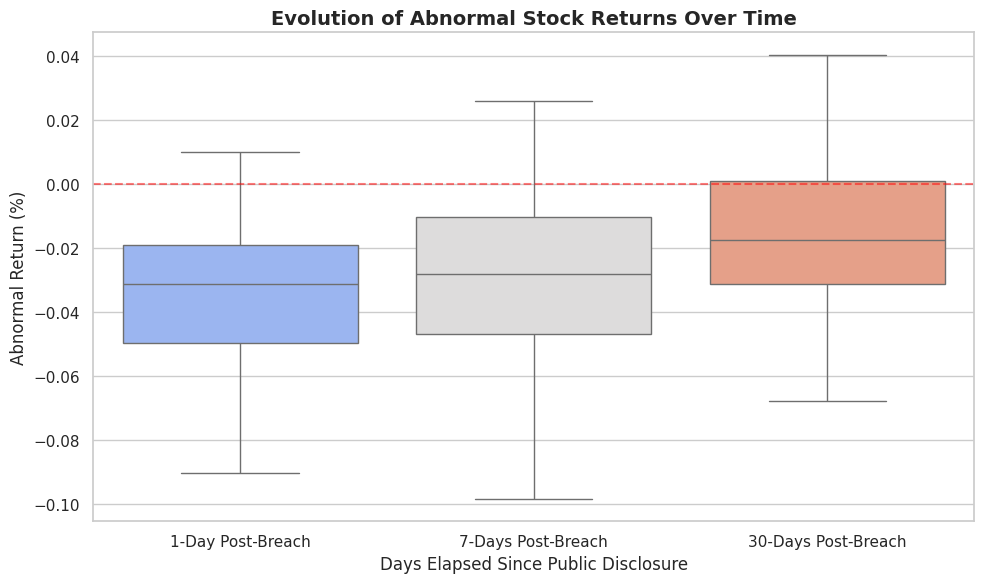

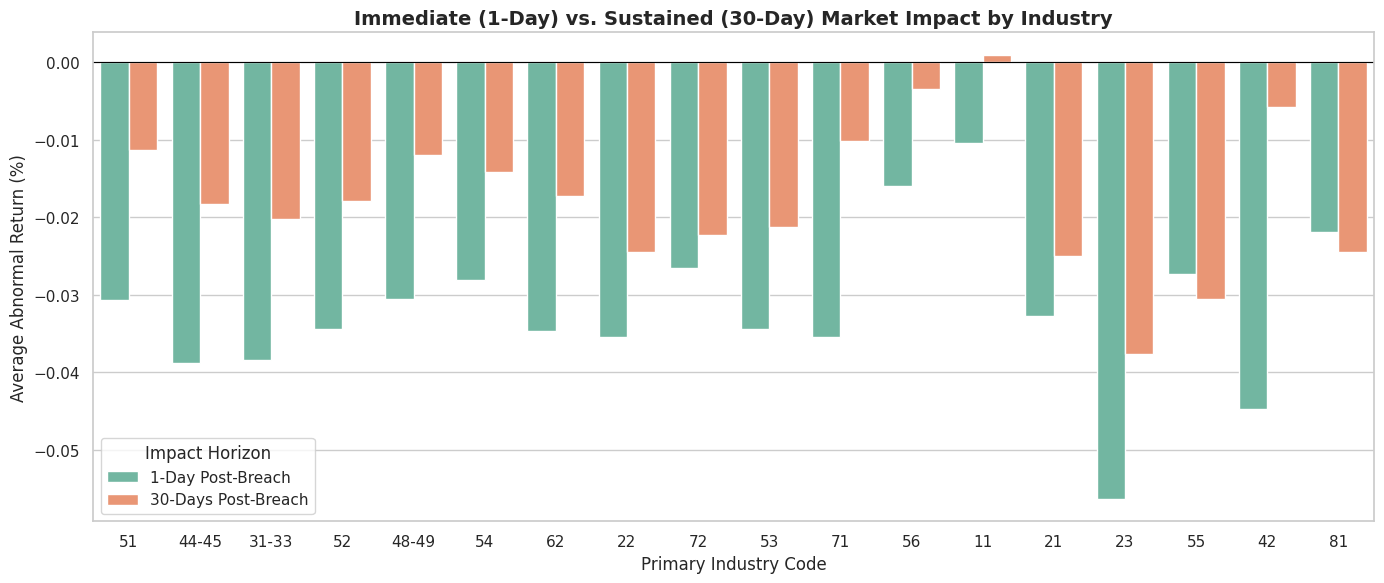

=== Mean Abnormal Returns over Time ===
abnormal_return_1d    -0.034183
abnormal_return_7d    -0.030746
abnormal_return_30d   -0.017018
dtype: float64

=== Median Abnormal Returns over Time ===
abnormal_return_1d    -0.031195
abnormal_return_7d    -0.028201
abnormal_return_30d   -0.017532
dtype: float64


In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Filter for public companies with valid stock market data
abnormal_cols = ['abnormal_return_1d', 'abnormal_return_7d', 'abnormal_return_30d']
public_impact_df = data[
    (data['is_public_company'] == True) & 
    (data[abnormal_cols].notna().any(axis=1))
].copy()


# 1. Timeline of Abnormal Returns (1-day vs. 7-day vs. 30-day)

# Melt the dataframe to long format for clean seaborn plotting
melted_returns = public_impact_df.melt(
    id_vars=['incident_id', 'industry_primary'],
    value_vars=abnormal_cols,
    var_name='Timeframe',
    value_name='Abnormal Return (%)'
)

# Clean up label names for the plot legend/axis
melted_returns['Timeframe'] = melted_returns['Timeframe'].map({
    'abnormal_return_1d': '1-Day Post-Breach',
    'abnormal_return_7d': '7-Days Post-Breach',
    'abnormal_return_30d': '30-Days Post-Breach'
})

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=melted_returns,
    x='Timeframe',
    y='Abnormal Return (%)',
    hue='Timeframe',
    palette='coolwarm',
    showfliers=False # Hide extreme outliers to focus on the overall distribution shift
)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Evolution of Abnormal Stock Returns Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Days Elapsed Since Public Disclosure', fontsize=12)
plt.ylabel('Abnormal Return (%)', fontsize=12)
plt.tight_layout()
plt.show()


# 2. Short vs. Long-term Impact by Industry

# Let's compare 1-day vs 30-day returns across primary industries
plt.figure(figsize=(14, 6))
sns.barplot(
    data=melted_returns[melted_returns['Timeframe'].isin(['1-Day Post-Breach', '30-Days Post-Breach'])],
    x='industry_primary',
    y='Abnormal Return (%)',
    hue='Timeframe',
    palette='Set2',
    errorbar=None
)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Immediate (1-Day) vs. Sustained (30-Day) Market Impact by Industry', fontsize=14, fontweight='bold')
plt.xlabel('Primary Industry Code', fontsize=12)
plt.ylabel('Average Abnormal Return (%)', fontsize=12)
plt.legend(title='Impact Horizon')
plt.tight_layout()
plt.show()


# 3. Quick Summary Stats

print("=== Mean Abnormal Returns over Time ===")
print(public_impact_df[abnormal_cols].mean())
print("\n=== Median Abnormal Returns over Time ===")
print(public_impact_df[abnormal_cols].median())

### **2. 💰 Financial Loss & Cost-Structure Deep Dive**

Cyber attacks are incredibly expensive, but where does the money actually go?

* **Loss Distribution (Skewness):** Plot a histogram/KDE of `total_loss_usd` and `direct_loss_usd`. *Tip: These are likely highly right-skewed, so you'll want to plot them on a Log Scale ($log_{10}$) to see the distribution clearly.*
* **The "Cost Breakdown" Stacked Bar Chart:** For the average incident, what percentage of `total_loss_usd` is driven by:
  * `direct_loss_usd` (Immediate operational damage)
  * `recovery_cost_usd` (Remediation & tech rebuilds)
  * `legal_fees_usd` (Lawyers & lawsuits)
  * `regulatory_fine_usd` (Compliance penalties)
* **Inflation Impact:** Plot `total_loss_usd` alongside `inflation_adjusted_loss_usd` over the 2021–2025 timeline to see if the real-dollar severity of cyber attacks is fundamentally climbing.

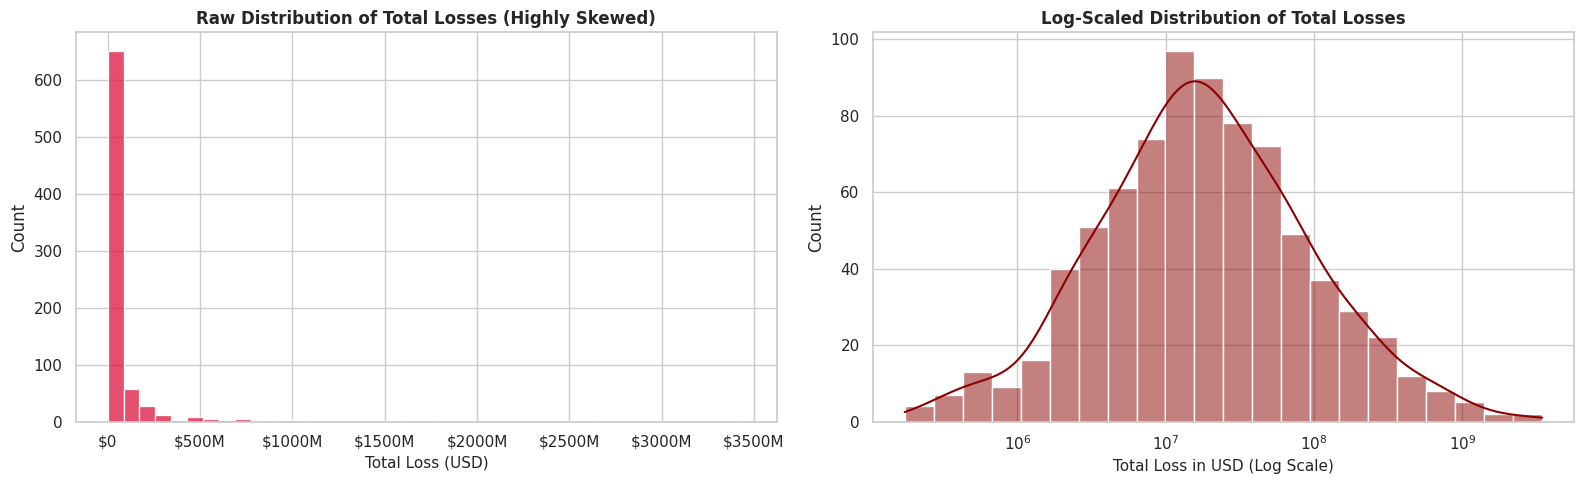

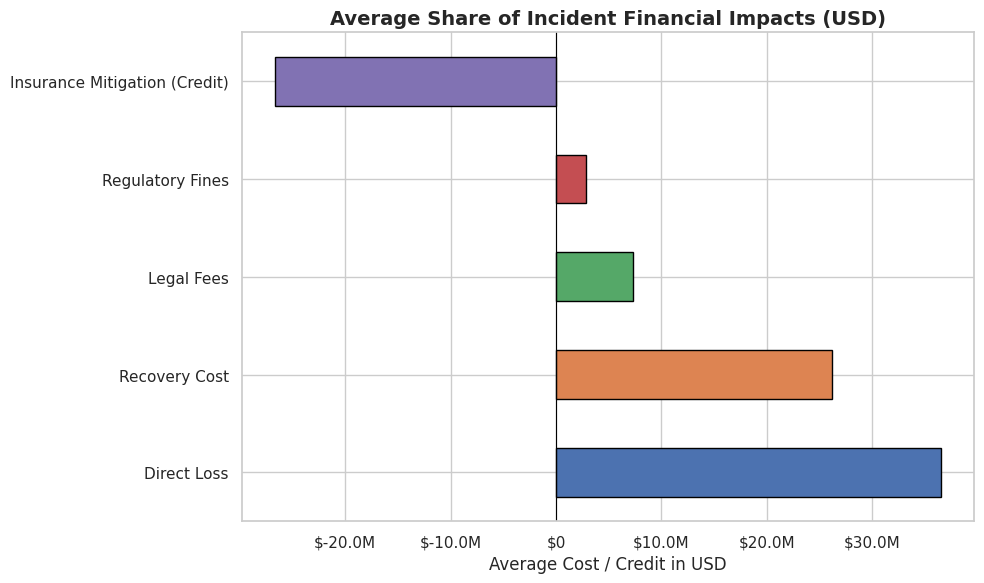

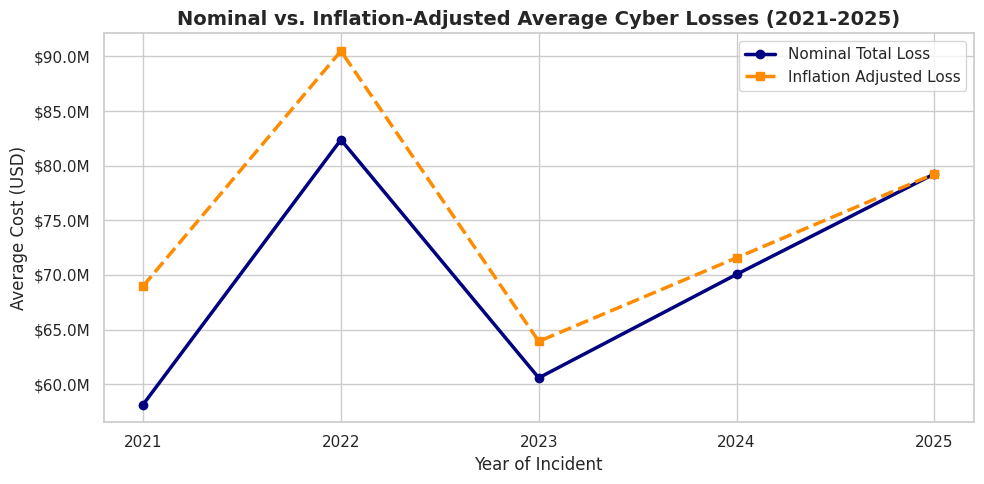

In [5]:
# Filter for records with valid financial metrics
financial_df = data[data['total_loss_usd'].notna()].copy()

# 1. Total Loss Distribution (Log-Scaled to Handle Massive Skew)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Standard distribution (Highly skewed)
sns.histplot(financial_df['total_loss_usd'], bins=40, ax=axes[0], color='crimson', kde=False)
axes[0].set_title('Raw Distribution of Total Losses (Highly Skewed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Loss (USD)', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.0f}M" if x >= 1e6 else f"${x:.0f}"))

# Log-scaled distribution for analytical clarity
sns.histplot(financial_df['total_loss_usd'], log_scale=True, ax=axes[1], color='darkred', kde=True)
axes[1].set_title('Log-Scaled Distribution of Total Losses', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Loss in USD (Log Scale)', fontsize=11)

plt.tight_layout()
plt.show()

# 2. Financial Breakdown: Where does the money go?
# Average out key financial sub-cost categories
cost_columns = {
    'Direct Loss': 'direct_loss_usd',
    'Recovery Cost': 'recovery_cost_usd',
    'Legal Fees': 'legal_fees_usd',
    'Regulatory Fines': 'regulatory_fine_usd',
    'Insurance Mitigation (Credit)': 'insurance_payout_usd'
}

# Average value across the entire dataset
avg_costs = {friendly_name: financial_df[col].mean() for friendly_name, col in cost_columns.items()}

# Subtract payouts because they mitigate costs
avg_costs['Insurance Mitigation (Credit)'] = -abs(avg_costs['Insurance Mitigation (Credit)'])

cost_series = pd.Series(avg_costs)

plt.figure(figsize=(10, 6))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
cost_series.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Average Share of Incident Financial Impacts (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Average Cost / Credit in USD', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if abs(x) >= 1e6 else f"${x:.0f}"))
plt.tight_layout()
plt.show()

# 3. Inflation Impact: Nominal vs. Inflation-Adjusted Over Time
# Make sure incident_date is datetime, and group by year
financial_df['incident_year'] = pd.to_datetime(financial_df['incident_date']).dt.year

# FIXED: Dynamically grab the exact inflation column name to avoid KeyErrors
inflation_col = [col for col in financial_df.columns if 'inflation' in col.lower()][0]
yearly_loss = financial_df.groupby('incident_year')[['total_loss_usd', inflation_col]].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_loss.index, yearly_loss['total_loss_usd'], marker='o', linewidth=2.5, label='Nominal Total Loss', color='navy')
plt.plot(yearly_loss.index, yearly_loss[inflation_col], marker='s', linewidth=2.5, label='Inflation Adjusted Loss', color='darkorange', linestyle='--')

plt.title('Nominal vs. Inflation-Adjusted Average Cyber Losses (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year of Incident', fontsize=12)
plt.ylabel('Average Cost (USD)', fontsize=12)
plt.xticks(yearly_loss.index)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))
plt.legend()
plt.tight_layout()
plt.show()

### **3. 🏢 Company Demographics & Vulnerability**

Who is getting targeted, and does size shield a company from damage?

* **Scale vs. Severity:** Run a correlation matrix between `employee_count` / `company_revenue` and `total_loss_usd`. Do larger organizations face exponentially higher costs, or is there a "flat rate" baseline for recovery?
* **Public vs. Private:** Compare the average `total_loss_usd` between public and private companies (`is_public_company`). Do public companies pay more due to regulatory exposure and public scrutiny?
* **Geographical Mapping:** Create a choropleth map using `country_hq` to show which countries host the companies experiencing the most frequent or most financially devastating attacks.

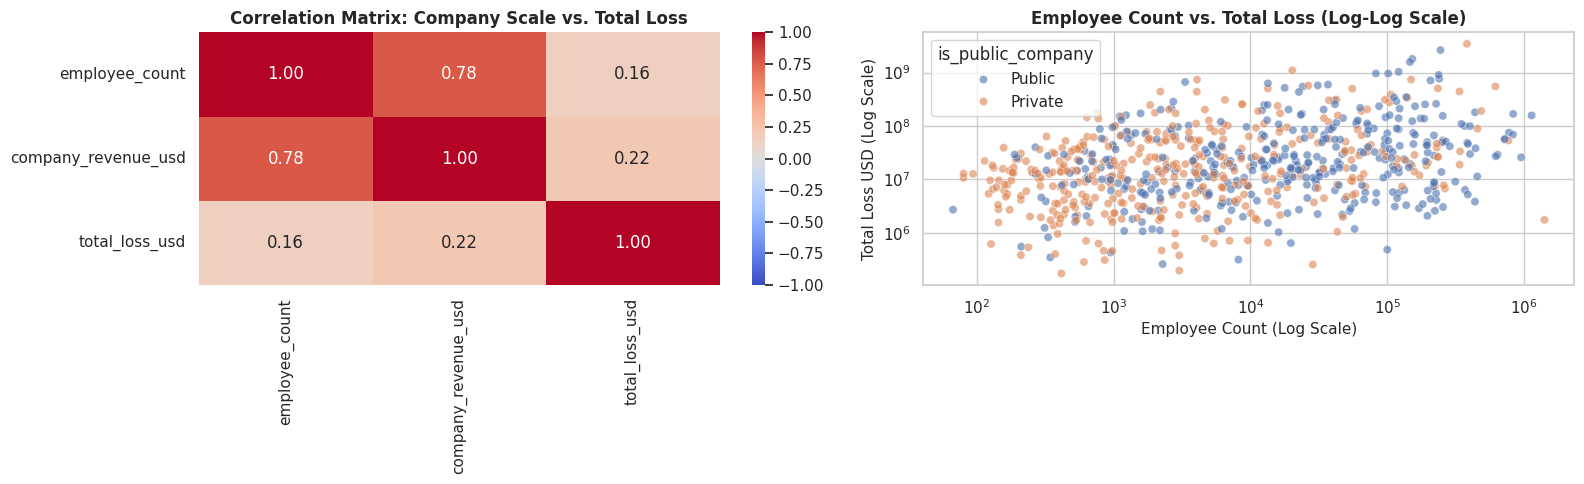

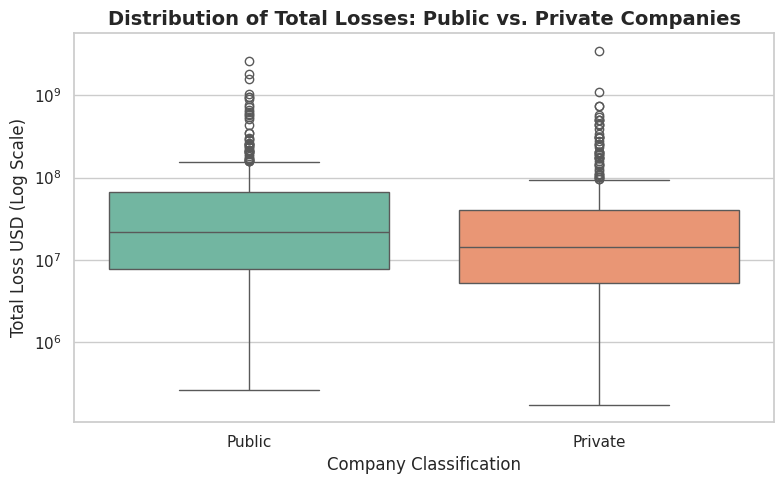

In [6]:
# Filter data for records with valid financial and demographic information
vulnerability_df = data[
    (data['total_loss_usd'].notna()) & 
    (data['employee_count'].notna())
].copy()

# Dynamically find the revenue column name (handles 'company_revenue' or 'company_revenue_usd')
revenue_col = [col for col in vulnerability_df.columns if 'revenue' in col.lower()][0]

# Convert is_public_company to a string type for clean plotting labels
vulnerability_df['is_public_company'] = vulnerability_df['is_public_company'].map({
    True: 'Public', False: 'Private'
})


# 1. Scale vs. Severity (Correlation & Scatter)

# Calculate Pearson correlation matrix
corr_cols = ['employee_count', revenue_col, 'total_loss_usd']
corr_matrix = vulnerability_df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt=".2f")
axes[0].set_title('Correlation Matrix: Company Scale vs. Total Loss', fontsize=12, fontweight='bold')

# Plot Scatter Plot (Employee Count vs Total Loss)
# Log scales used because employee counts and financial losses vary exponentially
sns.scatterplot(
    data=vulnerability_df, 
    x='employee_count', 
    y='total_loss_usd', 
    hue='is_public_company',
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Employee Count vs. Total Loss (Log-Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Employee Count (Log Scale)', fontsize=11)
axes[1].set_ylabel('Total Loss USD (Log Scale)', fontsize=11)

plt.tight_layout()
plt.show()


# 2. Public vs. Private Comparison

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=vulnerability_df, 
    x='is_public_company', 
    y='total_loss_usd', 
    hue='is_public_company',
    palette='Set2'
)
plt.yscale('log') # Log scale handles wide variance in financial damage
plt.title('Distribution of Total Losses: Public vs. Private Companies', fontsize=14, fontweight='bold')
plt.xlabel('Company Classification', fontsize=12)
plt.ylabel('Total Loss USD (Log Scale)', fontsize=12)
plt.tight_layout()
plt.show()


# 3. Geographical Mapping (Interactive Choropleth)

# Aggregate data by country of headquarters
country_stats = vulnerability_df.groupby('country_hq').agg(
    incident_count=('incident_id', 'count'),
    mean_total_loss=('total_loss_usd', 'mean')
).reset_index()

# Create interactive Choropleth Map highlighting total loss severity
fig_map = px.choropleth(
    country_stats,
    locations='country_hq',
    locationmode='country names', # Automatically maps country names to ISO codes
    color='mean_total_loss',
    hover_name='country_hq',
    hover_data={'incident_count': True, 'mean_total_loss': ':$,.2f'},
    color_continuous_scale=px.colors.sequential.Reds,
    title='Average Cyber Attack Financial Devastation by HQ Country'
)

fig_map.update_layout(
    coloraxis_colorbar_title="Mean Loss (USD)",
    geo=dict(showframe=False, showcoastlines=True)
)

fig_map.show()

### **4. 📅 Temporal & Trend Analysis (2021 - 2025)**

* **Seasonality:** Extract the month or quarter from `incident_date` to see if breaches spike during specific times of the year (e.g., holiday seasons or end-of-quarter financial closings).
* **Year-over-Year (YoY) Growth:** Track the average financial loss per incident from 2021 to 2025. Are cybercriminals getting more efficient at extracting value?